  MRI Beyin Tümörü Sınıflandırması — Derin Öğrenme ile Uçtan Uca Proje
  Brain Tumor MRI Classification using CNN & Transfer Learning (EfficientNetB3)
  
  Yazar     : [Adınız]
  Tarih     : 2025
  Ortam     : Google Colab (GPU önerilir)
  Veri Seti : https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

# BÖLÜM 0: Kurulum ve Kütüphane Yükleme
# ==============================================================================
# Google Colab'de Kaggle veri setini indirmek için:
# !pip install kaggle
# Kaggle API anahtarınızı yükledikten sonra:
# !kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
# !unzip brain-tumor-mri-dataset.zip -d /content/brain_tumor_data

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)

# Tekrar üretilebilirlik için seed belirleme
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow Sürümü:", tf.__version__)
print("GPU Kullanılabilir mi?:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow Sürümü: 2.19.0
GPU Kullanılabilir mi?: True


In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mehranhabibi134563","key":"c14d4e8730e3b3461a6e95a8be721655"}'}

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip brain-tumor-mri-dataset.zip -d /content/brain_tumor_data


Görüntülenen çıkış son 5000 satıra kısaltıldı.
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_279.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_28.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_280.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_281.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_282.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_283.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_284.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_285.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_286.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_287.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_288.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_289.jpg  
  inflating: /content/brain_tumor_data/Training/glioma/Tr-gl_29.jpg  
  inflating: /content/brain_tumo

BÖLÜM 1: Sabitler ve Konfigürasyon

In [ ]:
# Veri seti yolu (Colab'de indirdikten sonra güncelle)
DATA_DIR = "/content/brain_tumor_data"   # Colab için
# DATA_DIR = "./brain_tumor_data"         # Yerel çalışma için

TRAIN_DIR = os.path.join(DATA_DIR, "Training")
TEST_DIR  = os.path.join(DATA_DIR, "Testing")

IMG_SIZE    = (224, 224)   # EfficientNet ve CNN için standart boyut
BATCH_SIZE  = 32
EPOCHS_CNN  = 30
EPOCHS_TFER = 20
NUM_CLASSES = 4

CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]


 BÖLÜM 2: Veri Ön İşleme ve Augmentation

In [ ]:
def create_data_generators():
    """
    Eğitim verisine augmentation, doğrulama/test verisine yalnızca
    normalizasyon uygulayan ImageDataGenerator'lar oluşturur.

    Augmentation stratejisi:
    - Yatay çevirme: gerçek MRI'larda görülebilir varyasyonu taklit eder
    - Döndürme (±15°): küçük pozisyon farklılıklarını kapsar
    - Yakınlaştırma (±10%): tarama mesafesi değişkenliğini simüle eder
    - Parlaklık (±20%): farklı tarama protokollerini modeller
    - Shear: hafif geometrik bozulma
    - Normalizasyon: piksel değerleri [0,1] aralığına çekilir
    """
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        validation_split=0.2   # Eğitim verisinin %20'si doğrulama için
    )

    # Test ve doğrulama için yalnızca normalizasyon
    val_test_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        subset="training",
        shuffle=True,
        seed=42
    )

    val_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        subset="validation",
        shuffle=False,
        seed=42
    )

    test_generator = val_test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    return train_generator, val_generator, test_generator


def visualize_samples(generator, n=12):
    """Veri setinden örnek görüntüleri sınıf etiketleriyle göster."""
    images, labels = next(generator)
    class_indices = {v: k for k, v in generator.class_indices.items()}

    plt.figure(figsize=(16, 8))
    for i in range(min(n, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i])
        label_idx = np.argmax(labels[i])
        plt.title(f"Sınıf: {class_indices[label_idx]}", fontsize=9)
        plt.axis("off")
    plt.suptitle("Veri Setinden Örnek MRI Görüntüleri", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Örnek görüntüler kaydedildi: sample_images.png")

BÖLÜM 3A: Model 1 — Özel CNN Mimarisi

In [ ]:
def build_custom_cnn(input_shape=(224, 224, 3), num_classes=4):
    """
    Sıfırdan tasarlanmış özel bir CNN mimarisi.

    Mimari Gerekçesi:
    - 3 aşamalı Conv blok: her blok Conv→BN→ReLU→MaxPool hiyerarşisi ile
      özellik haritalarını giderek soyutlaştırır.
    - Batch Normalization: eğitimi hızlandırır, iç kovaryans kaymasını azaltır.
    - Dropout (0.5): tam bağlantı katmanlarında aşırı öğrenmeyi engeller.
    - Global Average Pooling: parametre sayısını düşürür, uzamsal bilgiyi korur.
    """
    model = models.Sequential([
        # --- Blok 1: Düşük Seviye Özellikler (kenarlar, dokular) ---
        layers.Conv2D(32, (3,3), activation="relu", padding="same",
                      input_shape=input_shape, name="conv1_1"),
        layers.BatchNormalization(name="bn1_1"),
        layers.Conv2D(32, (3,3), activation="relu", padding="same", name="conv1_2"),
        layers.BatchNormalization(name="bn1_2"),
        layers.MaxPooling2D(2, 2, name="pool1"),
        layers.Dropout(0.25, name="drop1"),

        # --- Blok 2: Orta Seviye Özellikler (şekiller, yapılar) ---
        layers.Conv2D(64, (3,3), activation="relu", padding="same", name="conv2_1"),
        layers.BatchNormalization(name="bn2_1"),
        layers.Conv2D(64, (3,3), activation="relu", padding="same", name="conv2_2"),
        layers.BatchNormalization(name="bn2_2"),
        layers.MaxPooling2D(2, 2, name="pool2"),
        layers.Dropout(0.25, name="drop2"),

        # --- Blok 3: Yüksek Seviye Özellikler (tümör morfolojisi) ---
        layers.Conv2D(128, (3,3), activation="relu", padding="same", name="conv3_1"),
        layers.BatchNormalization(name="bn3_1"),
        layers.Conv2D(128, (3,3), activation="relu", padding="same", name="conv3_2"),
        layers.BatchNormalization(name="bn3_2"),
        layers.MaxPooling2D(2, 2, name="pool3"),
        layers.Dropout(0.25, name="drop3"),

        # --- Sınıflandırıcı Baş ---
        layers.GlobalAveragePooling2D(name="gap"),
        layers.Dense(256, activation="relu", name="fc1"),
        layers.BatchNormalization(name="bn_fc"),
        layers.Dropout(0.5, name="drop_fc"),
        layers.Dense(num_classes, activation="softmax", name="output")
    ], name="Custom_CNN")

    return model


BÖLÜM 3B: Model 2 — Transfer Learning (EfficientNetB3)

In [ ]:
def build_transfer_model(input_shape=(224, 224, 3), num_classes=4):
    """
    ImageNet ağırlıkları ile ön-eğitilmiş EfficientNetB3 tabanlı
    transfer öğrenme modeli.

    Mimari Gerekçesi:
    - EfficientNetB3: Bileşik ölçekleme ile genişlik/derinlik/çözünürlüğü
      dengeli artıran verimli mimari; tıbbi görüntülemede üstün performans.
    - Aşamalı Fine-tuning:
        Aşama 1 — Taban dondurulmuş, yalnızca yeni katmanlar eğitilir.
        Aşama 2 — Son 30 katman çözülür, düşük LR ile ince ayar yapılır.
    - Global Average Pooling + Dense + Dropout: overfitting'i baskılar.
    """
    base_model = EfficientNetB3(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False   # Aşama 1: Taban donduruldu

    inputs  = layers.Input(shape=input_shape, name="input")
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D(name="gap")(x)
    x       = layers.Dense(256, activation="relu", name="fc1")(x)
    x       = layers.BatchNormalization(name="bn_fc")(x)
    x       = layers.Dropout(0.5, name="drop_fc")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = keras.Model(inputs, outputs, name="EfficientNetB3_Transfer")
    return model, base_model

 BÖLÜM 4: Model Eğitimi

In [ ]:
def get_callbacks(model_name, patience_es=7, patience_lr=4):
    """
    Early Stopping, LR azaltma ve model kaydetme callback'leri döndürür.

    - EarlyStopping: val_loss iyileşmediğinde durur, en iyi ağırlıkları geri yükler.
    - ReduceLROnPlateau: öğrenme hızını otomatik düşürerek zor platolardan çıkar.
    - ModelCheckpoint: her epoch'ta en iyi modeli diske yazar.
    """
    return [
        EarlyStopping(
            monitor="val_loss", patience=patience_es,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=patience_lr,
            min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            f"best_{model_name}.h5", monitor="val_accuracy",
            save_best_only=True, verbose=0
        )
    ]


def train_cnn(train_gen, val_gen):
    """Özel CNN modelini derle ve eğit."""
    model = build_custom_cnn()
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    model.summary()

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_CNN,
        callbacks=get_callbacks("cnn"),
        verbose=1
    )
    return model, history


def train_transfer(train_gen, val_gen):
    """
    EfficientNetB3 modelini iki aşamalı stratejiyle eğit:
      Aşama 1: Yalnızca yeni baş katmanlar (10 epoch)
      Aşama 2: Son 30 katman çözülür, ince ayar (10 epoch)
    """
    model, base_model = build_transfer_model()

    # === Aşama 1: Taban dondurulmuş ===
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    print("\n--- Aşama 1: Transfer Learning (Taban Dondurulmuş) ---")
    history_phase1 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=get_callbacks("transfer_phase1"),
        verbose=1
    )

    # === Aşama 2: Son 30 katman çözüldü (Fine-Tuning) ===
    base_model.trainable = True
    fine_tune_at = len(base_model.layers) - 30
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-5),   # Çok düşük LR kritik!
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    print("\n--- Aşama 2: Fine-Tuning (Son 30 Katman) ---")
    history_phase2 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_TFER,
        callbacks=get_callbacks("transfer_phase2"),
        verbose=1
    )

    # İki aşamanın geçmişlerini birleştir
    combined = {}
    for key in history_phase1.history:
        combined[key] = history_phase1.history[key] + history_phase2.history[key]

    class CombinedHistory:
        history = combined

    return model, CombinedHistory()

BÖLÜM 5: Model Değerlendirme

In [ ]:
def evaluate_model(model, test_gen, model_name="Model"):
    """
    Test seti üzerinde kapsamlı değerlendirme:
    Accuracy, Precision, Recall, F1-score ve Confusion Matrix.
    """
    test_gen.reset()
    y_pred_proba = model.predict(test_gen, verbose=0)
    y_pred  = np.argmax(y_pred_proba, axis=1)
    y_true  = test_gen.classes
    labels  = list(test_gen.class_indices.keys())

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted")
    rec  = recall_score(y_true, y_pred, average="weighted")
    f1   = f1_score(y_true, y_pred, average="weighted")

    print(f"\n{'='*55}")
    print(f"  {model_name} — Test Seti Değerlendirme Sonuçları")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"{'='*55}\n")
    print(classification_report(y_true, y_pred, target_names=labels))

    return y_true, y_pred, labels, {"accuracy": acc, "precision": prec,
                                     "recall": rec, "f1": f1}

BÖLÜM 6: Görselleştirme

In [ ]:
def plot_training_history(history, model_name="Model"):
    """Eğitim/doğrulama accuracy ve loss eğrilerini çiz."""
    h = history.history
    epochs = range(1, len(h["accuracy"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Eğitim Geçmişi", fontsize=14, fontweight="bold")

    # Accuracy
    axes[0].plot(epochs, h["accuracy"], "b-o", markersize=4, label="Eğitim")
    axes[0].plot(epochs, h["val_accuracy"], "r-o", markersize=4, label="Doğrulama")
    axes[0].set_title("Model Doğruluğu (Accuracy)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs, h["loss"], "b-o", markersize=4, label="Eğitim")
    axes[1].plot(epochs, h["val_loss"], "r-o", markersize=4, label="Doğrulama")
    axes[1].set_title("Model Kayıp Fonksiyonu (Loss)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f"{model_name.replace(' ', '_')}_training_history.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Kaydedildi: {fname}")


def plot_confusion_matrix(y_true, y_pred, labels, model_name="Model"):
    """Normalize edilmiş ve ham confusion matrix yan yana."""
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Karışıklık Matrisi", fontsize=14, fontweight="bold")

    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_pct],
        ["d", ".2f"],
        ["Gerçek Sayılar", "Normalize (Oranlar)"]
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=labels, yticklabels=labels,
                    linewidths=0.5, ax=ax, cbar=True)
        ax.set_title(title)
        ax.set_xlabel("Tahmin Edilen Sınıf")
        ax.set_ylabel("Gerçek Sınıf")
        ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    fname = f"{model_name.replace(' ', '_')}_confusion_matrix.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Kaydedildi: {fname}")


def plot_sample_predictions(model, test_gen, n=12, model_name="Model"):
    """Rastgele test örnekleri üzerinde tahminleri gerçek etiketiyle göster."""
    test_gen.reset()
    images, labels = next(test_gen)
    preds   = model.predict(images, verbose=0)
    idx_map = {v: k for k, v in test_gen.class_indices.items()}

    plt.figure(figsize=(16, 9))
    for i in range(min(n, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i])
        true_cls = idx_map[np.argmax(labels[i])]
        pred_cls = idx_map[np.argmax(preds[i])]
        conf     = np.max(preds[i]) * 100
        color    = "green" if true_cls == pred_cls else "red"
        plt.title(f"G: {true_cls}\nT: {pred_cls} ({conf:.1f}%)",
                  color=color, fontsize=8)
        plt.axis("off")
    plt.suptitle(f"{model_name} — Örnek Tahminler (Yeşil=Doğru, Kırmızı=Yanlış)",
                 fontsize=12)
    plt.tight_layout()
    fname = f"{model_name.replace(' ', '_')}_sample_preds.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Kaydedildi: {fname}")


def plot_model_comparison(results_dict):
    """İki modelin metriklerini grouped bar chart ile karşılaştır."""
    metrics = ["accuracy", "precision", "recall", "f1"]
    x       = np.arange(len(metrics))
    width   = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    model_names = list(results_dict.keys())
    colors      = ["#2196F3", "#4CAF50"]

    for i, (name, res) in enumerate(results_dict.items()):
        vals = [res[m] for m in metrics]
        bars = ax.bar(x + i * width, vals, width,
                      label=name, color=colors[i], alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9)

    ax.set_ylim(0, 1.08)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(["Accuracy", "Precision", "Recall", "F1-Score"])
    ax.set_ylabel("Skor")
    ax.set_title("Model Karşılaştırması — Test Seti Metrikleri", fontsize=13)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Kaydedildi: model_comparison.png")

BÖLÜM 9 (BONUS): Grad-CAM — Açıklanabilir Yapay Zeka

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Gradient-weighted Class Activation Mapping (Grad-CAM) ısı haritası üretir.

    Yöntem:
    1. Son konvolüsyon katmanına kadar olan modeli elde et.
    2. Bu katmanın çıktısına ve son tahmine göre gradyanları hesapla.
    3. Gradyanların ortalama pooling'i → her özellik haritasının önem ağırlığı.
    4. Ağırlıklı özelliklerin toplamı → sınıfa özgü aktivasyon haritası.
    5. ReLU → negatif aktivasyonları sıfırla (ilgisiz bölgeler).
    """
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads       = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def display_gradcam(model, img_path, last_conv_layer_name,
                    class_names=CLASS_NAMES, alpha=0.5):
    """
    Orijinal MRI görüntüsü üzerine Grad-CAM ısı haritasını bindirerek
    modelin karar bölgelerini görselleştirir.

    Yorumlama:
    - Kırmızı/sarı bölgeler: modelin sınıflandırma kararına en fazla katkıda
      bulunan anatomik bölgeler (tümörün bulunduğu alan).
    - Mavi/mor bölgeler: düşük katkı — model bu bölgeleri görmezden gelmiş.
    """
    img       = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds      = model.predict(img_array, verbose=0)
    pred_idx   = np.argmax(preds[0])
    pred_class = class_names[pred_idx]
    confidence = preds[0][pred_idx] * 100

    heatmap   = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_idx)

    # Isı haritasını orijinal boyuta ölçekle ve renklendirme uygula
    heatmap_resized = np.uint8(255 * heatmap)
    jet_colors      = cm.jet(np.arange(256))[:, :3]
    jet_heatmap     = jet_colors[heatmap_resized]
    jet_heatmap     = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap     = jet_heatmap.resize(IMG_SIZE)
    jet_heatmap     = img_to_array(jet_heatmap) / 255.0

    original = np.array(img) / 255.0
    superimposed = jet_heatmap * alpha + original * (1 - alpha)
    superimposed = np.clip(superimposed, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Grad-CAM Analizi | Tahmin: {pred_class} ({confidence:.1f}%)",
                 fontsize=13, fontweight="bold")

    axes[0].imshow(original)
    axes[0].set_title("Orijinal MRI")
    axes[0].axis("off")

    axes[1].imshow(jet_heatmap)
    axes[1].set_title("Grad-CAM Isı Haritası")
    axes[1].axis("off")

    axes[2].imshow(superimposed)
    axes[2].set_title("Bindirme (Overlay)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig("gradcam_visualization.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Kaydedildi: gradcam_visualization.png")
    print(f"Grad-CAM Yorumu: Model, '{pred_class}' sınıfını tahmin etmek için")
    print("  görüntünün kırmızı/sarı bölgelerine odaklanmıştır.")

BÖLÜM 7 (ANA AKIŞ): Her Şeyi Bir Araya Getir


  MRI Beyin Tümörü Sınıflandırması — Başlıyor...

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Eğitim görüntüsü  : 4480
Doğrulama görüntüsü: 1120
Test görüntüsü     : 1600
Sınıflar           : ['glioma', 'meningioma', 'notumor', 'pituitary']


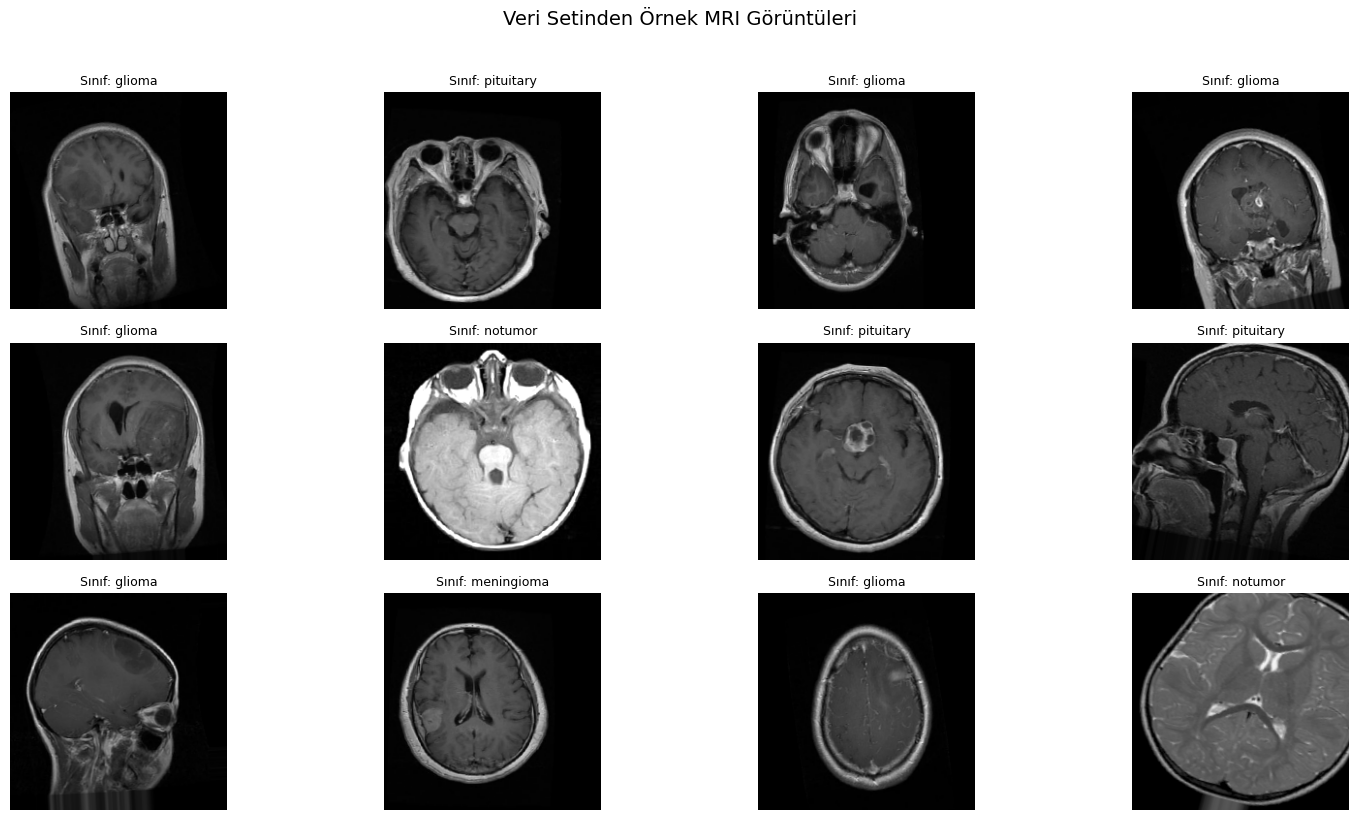

Örnek görüntüler kaydedildi: sample_images.png


--- MODEL A: ÖZEL CNN EĞİTİLİYOR ---


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_fc (BatchNormalization)      │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,876 (1.24 MB)

 Trainable params: 322,468 (1.23 MB)

...

140/140 ━━━━━━━━━━━━━━━━━━━━ 88s 626ms/step - accuracy: 0.8853 - loss: 0.3155 - val_accuracy: 0.8446 - val_loss: 0.4066 - learning_rate: 5.0000e-04
Epoch 16/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 87s 619ms/step - accuracy: 0.8886 - loss: 0.2992 - val_accuracy: 0.7679 - val_loss: 0.7469 - learning_rate: 5.0000e-04
Epoch 17/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 87s 621ms/step - accuracy: 0.8920 - loss: 0.3028 - val_accuracy: 0.8393 - val_loss: 0.4199 - learning_rate: 5.0000e-04
Epoch 18/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.8976 - loss: 0.2765

140/140 ━━━━━━━━━━━━━━━━━━━━ 87s 622ms/step - accuracy: 0.9002 - loss: 0.2736 - val_accuracy: 0.8830 - val_loss: 0.2764 - learning_rate: 5.0000e-04
Epoch 19/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 86s 616ms/step - accuracy: 0.9054 - loss: 0.2715 - val_accuracy: 0.6652 - val_loss: 1.1833 - learning_rate: 5.0000e-04
Epoch 20/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 88s 627ms/step - accuracy: 0.9002 - loss: 0.2621 - val_accuracy: 0.8821 - val_loss: 0.2971 - learning_rate: 5.0000e-04
Epoch 21/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 87s 620ms/step - accuracy: 0.9062 - loss: 0.2500 - val_accuracy: 0.6080 - val_loss: 2.6720 - learning_rate: 5.0000e-04
Epoch 22/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.9028 - loss: 0.2522
Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
140/140 ━━━━━━━━━━━━━━━━━━━━ 88s 628ms/step - accuracy: 0.9033 - loss: 0.2600 - val_accuracy: 0.8455 - val_loss: 0.4506 - learning_rate: 5.0000e-04
Epoch 23/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - a

140/140 ━━━━━━━━━━━━━━━━━━━━ 87s 623ms/step - accuracy: 0.9208 - loss: 0.2121 - val_accuracy: 0.9214 - val_loss: 0.2069 - learning_rate: 2.5000e-04
Epoch 24/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 139s 600ms/step - accuracy: 0.9304 - loss: 0.1876 - val_accuracy: 0.8652 - val_loss: 0.3610 - learning_rate: 2.5000e-04
Epoch 25/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 86s 616ms/step - accuracy: 0.9315 - loss: 0.1845 - val_accuracy: 0.8786 - val_loss: 0.3136 - learning_rate: 2.5000e-04
Epoch 26/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 86s 615ms/step - accuracy: 0.9297 - loss: 0.1872 - val_accuracy: 0.9062 - val_loss: 0.2336 - learning_rate: 2.5000e-04
Epoch 27/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.9189 - loss: 0.2047
Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
140/140 ━━━━━━━━━━━━━━━━━━━━ 84s 600ms/step - accuracy: 0.9290 - loss: 0.1906 - val_accuracy: 0.9089 - val_loss: 0.2379 - learning_rate: 2.5000e-04
Epoch 28/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 85s 602ms/step -

140/140 ━━━━━━━━━━━━━━━━━━━━ 89s 639ms/step - accuracy: 0.9404 - loss: 0.1630 - val_accuracy: 0.9268 - val_loss: 0.1974 - learning_rate: 1.2500e-04
Epoch 30/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.9480 - loss: 0.1441

140/140 ━━━━━━━━━━━━━━━━━━━━ 89s 636ms/step - accuracy: 0.9471 - loss: 0.1529 - val_accuracy: 0.9321 - val_loss: 0.1795 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 30.


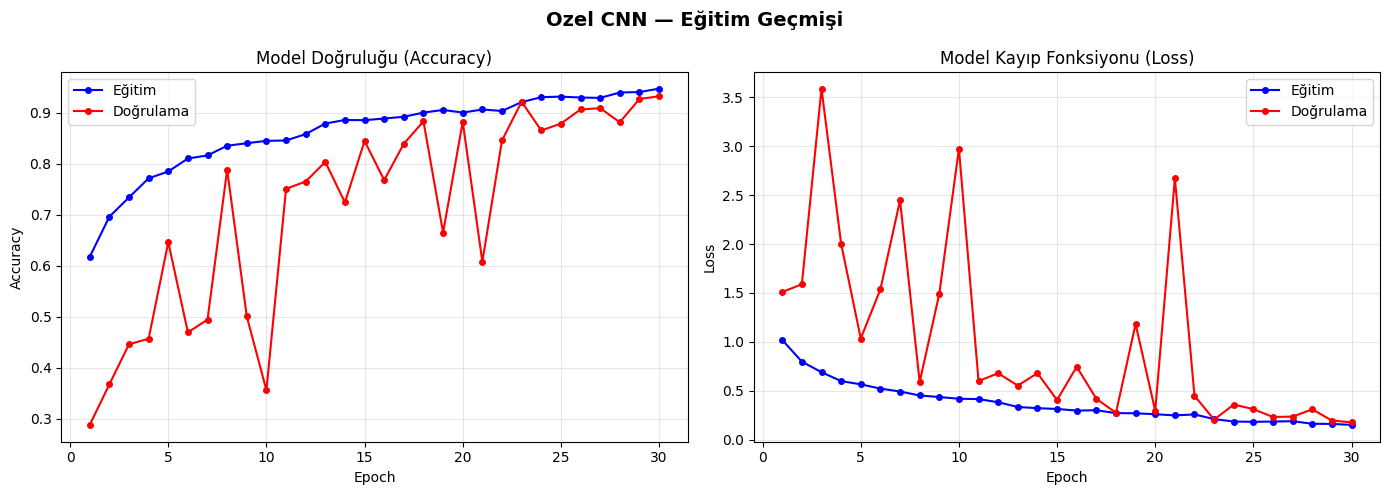

Kaydedildi: Ozel_CNN_training_history.png

  Ozel CNN — Test Seti Değerlendirme Sonuçları
  Accuracy  : 0.8650  (86.50%)
  Precision : 0.8750
  Recall    : 0.8650
  F1-Score  : 0.8596

              precision    recall  f1-score   support

      glioma       0.97      0.67      0.79       400
  meningioma       0.84      0.79      0.82       400
     notumor       0.86      1.00      0.93       400
   pituitary       0.83      1.00      0.90       400

    accuracy                           0.86      1600
   macro avg       0.88      0.86      0.86      1600
weighted avg       0.88      0.86      0.86      1600



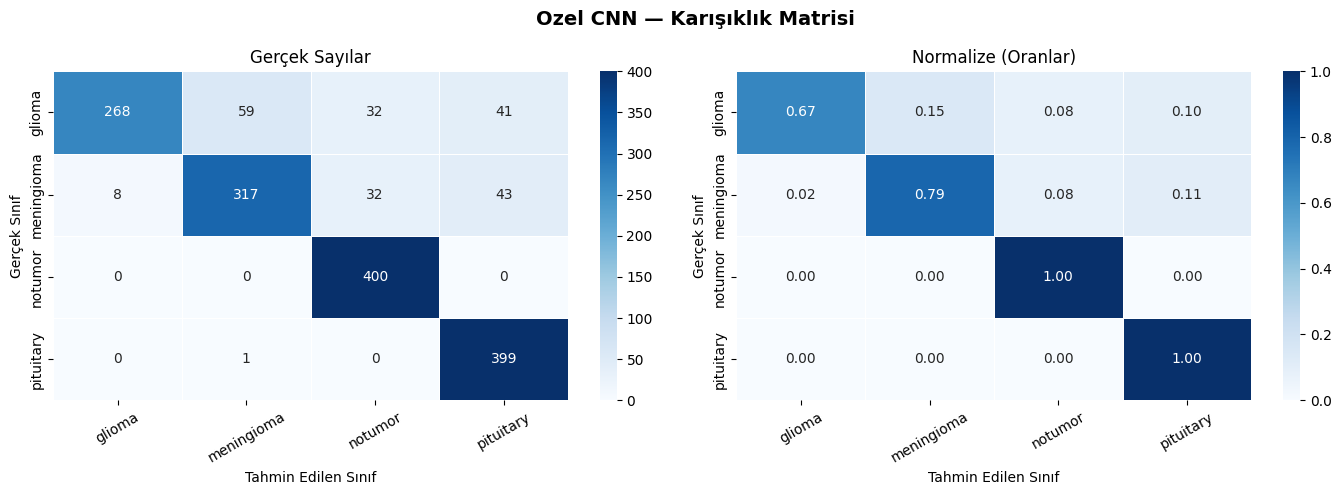

Kaydedildi: Ozel_CNN_confusion_matrix.png


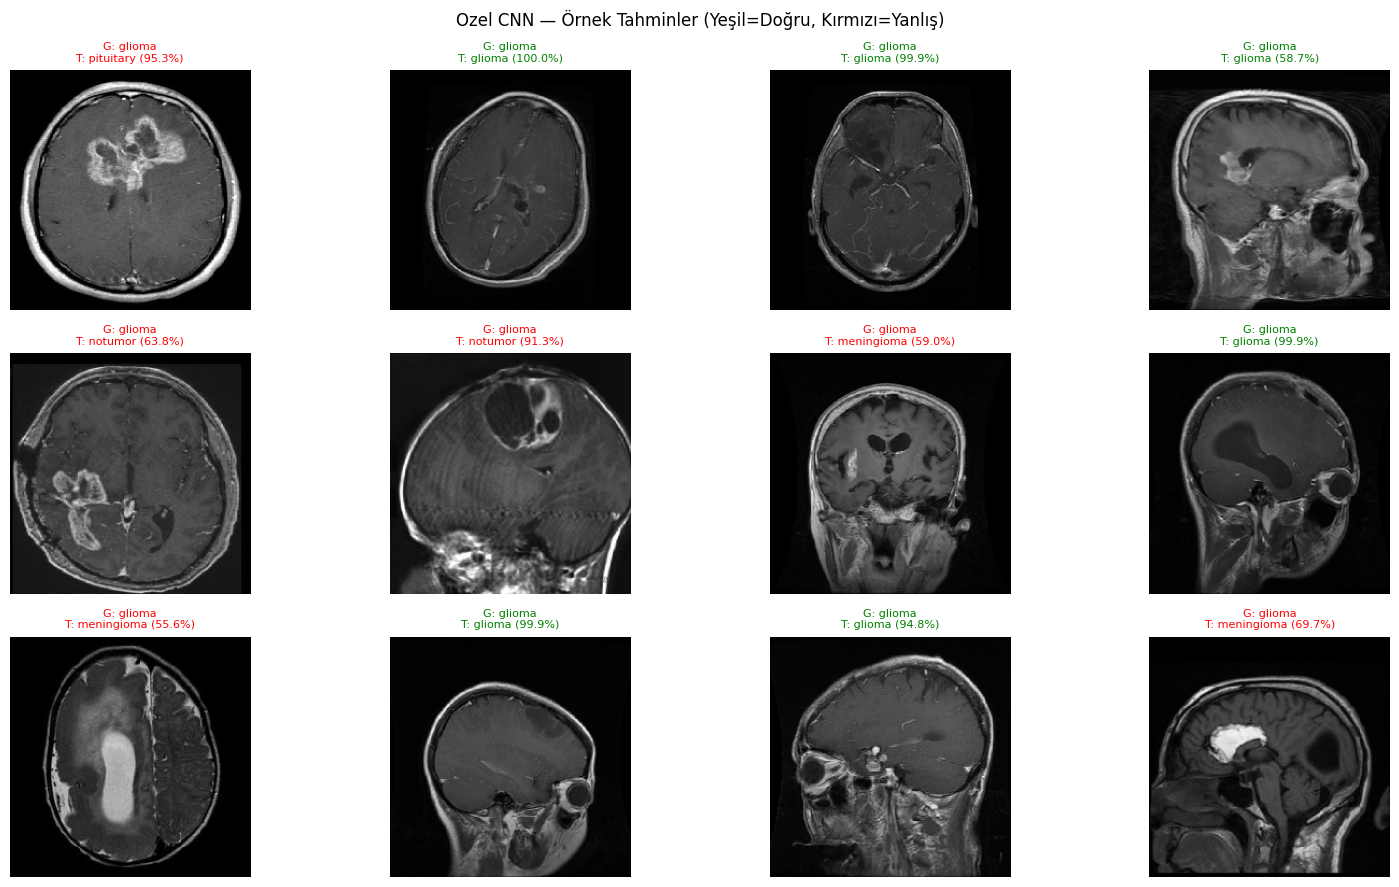

Kaydedildi: Ozel_CNN_sample_preds.png


--- MODEL B: EfficientNetB3 TRANSFER EĞİTİLİYOR ---
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Aşama 1: Transfer Learning (Taban Dondurulmuş) ---
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.3669 - loss: 1.4316

140/140 ━━━━━━━━━━━━━━━━━━━━ 151s 731ms/step - accuracy: 0.3944 - loss: 1.3569 - val_accuracy: 0.3080 - val_loss: 1.5399 - learning_rate: 0.0010
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.4117 - loss: 1.2653

140/140 ━━━━━━━━━━━━━━━━━━━━ 89s 636ms/step - accuracy: 0.4283 - loss: 1.2527 - val_accuracy: 0.3902 - val_loss: 1.2966 - learning_rate: 0.0010
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 87s 619ms/step - accuracy: 0.4413 - loss: 1.2320 - val_accuracy: 0.2884 - val_loss: 1.4057 - learning_rate: 0.0010
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.4276 - loss: 1.2179

140/140 ━━━━━━━━━━━━━━━━━━━━ 88s 632ms/step - accuracy: 0.4455 - loss: 1.2098 - val_accuracy: 0.4384 - val_loss: 1.1518 - learning_rate: 0.0010
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 140s 619ms/step - accuracy: 0.4676 - loss: 1.1940 - val_accuracy: 0.2991 - val_loss: 1.5540 - learning_rate: 0.0010
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 87s 623ms/step - accuracy: 0.4663 - loss: 1.1681 - val_accuracy: 0.3455 - val_loss: 1.6828 - learning_rate: 0.0010
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.4684 - loss: 1.1786

140/140 ━━━━━━━━━━━━━━━━━━━━ 88s 630ms/step - accuracy: 0.4571 - loss: 1.1802 - val_accuracy: 0.4732 - val_loss: 1.1593 - learning_rate: 0.0010
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.4680 - loss: 1.1704
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
140/140 ━━━━━━━━━━━━━━━━━━━━ 87s 624ms/step - accuracy: 0.4768 - loss: 1.1602 - val_accuracy: 0.4500 - val_loss: 1.1690 - learning_rate: 0.0010
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 87s 620ms/step - accuracy: 0.4891 - loss: 1.1321 - val_accuracy: 0.2536 - val_loss: 1.4828 - learning_rate: 5.0000e-04
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 87s 622ms/step - accuracy: 0.4801 - loss: 1.1503 - val_accuracy: 0.4330 - val_loss: 1.1081 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 10.

--- Aşama 2: Fine-Tuning (Son 30 Katman) ---
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.3602 - loss: 1.5820

...

140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 582ms/step - accuracy: 0.4839 - loss: 1.1775 - val_accuracy: 0.4902 - val_loss: 1.1585 - learning_rate: 5.0000e-06
Epoch 16/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.4887 - loss: 1.1824

140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 590ms/step - accuracy: 0.4857 - loss: 1.1641 - val_accuracy: 0.4911 - val_loss: 1.1562 - learning_rate: 5.0000e-06
Epoch 17/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.4908 - loss: 1.1590

140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 581ms/step - accuracy: 0.4900 - loss: 1.1564 - val_accuracy: 0.5045 - val_loss: 1.1139 - learning_rate: 5.0000e-06
Epoch 18/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.4941 - loss: 1.1600

140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 585ms/step - accuracy: 0.4998 - loss: 1.1378 - val_accuracy: 0.5152 - val_loss: 1.0849 - learning_rate: 5.0000e-06
Epoch 19/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 575ms/step - accuracy: 0.4833 - loss: 1.1524 - val_accuracy: 0.5009 - val_loss: 1.1249 - learning_rate: 5.0000e-06
Epoch 20/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.4724 - loss: 1.1670

140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 588ms/step - accuracy: 0.4846 - loss: 1.1504 - val_accuracy: 0.5357 - val_loss: 1.0647 - learning_rate: 5.0000e-06
Restoring model weights from the end of the best epoch: 20.


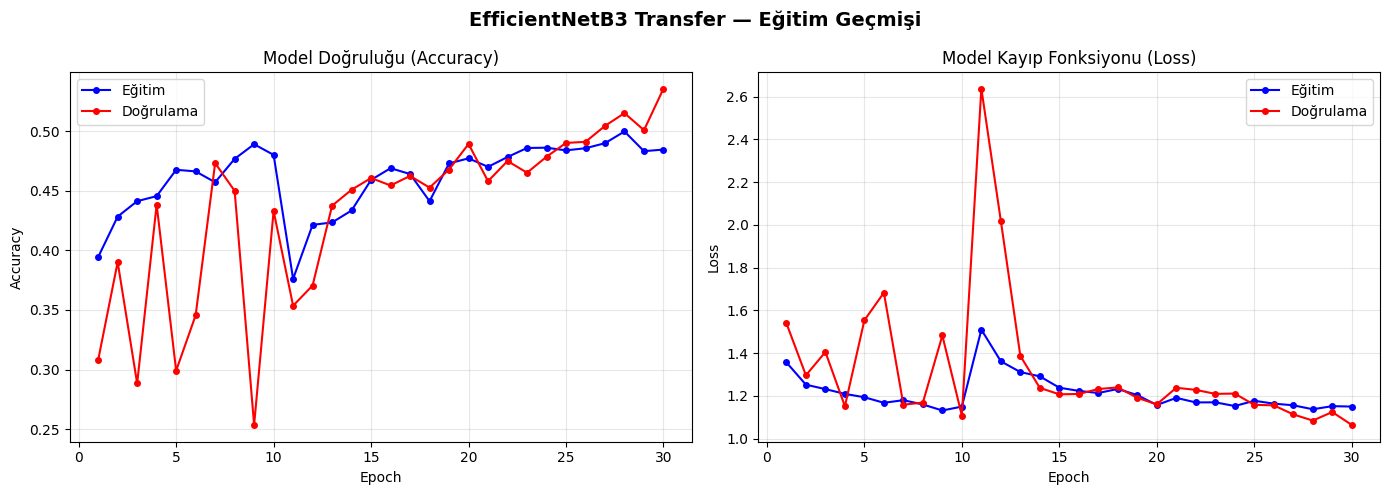

Kaydedildi: EfficientNetB3_Transfer_training_history.png

  EfficientNetB3 Transfer — Test Seti Değerlendirme Sonuçları
  Accuracy  : 0.5713  (57.12%)
  Precision : 0.5823
  Recall    : 0.5713
  F1-Score  : 0.5633

              precision    recall  f1-score   support

      glioma       0.50      0.66      0.57       400
  meningioma       0.53      0.30      0.39       400
     notumor       0.77      0.65      0.70       400
   pituitary       0.54      0.68      0.60       400

    accuracy                           0.57      1600
   macro avg       0.58      0.57      0.56      1600
weighted avg       0.58      0.57      0.56      1600



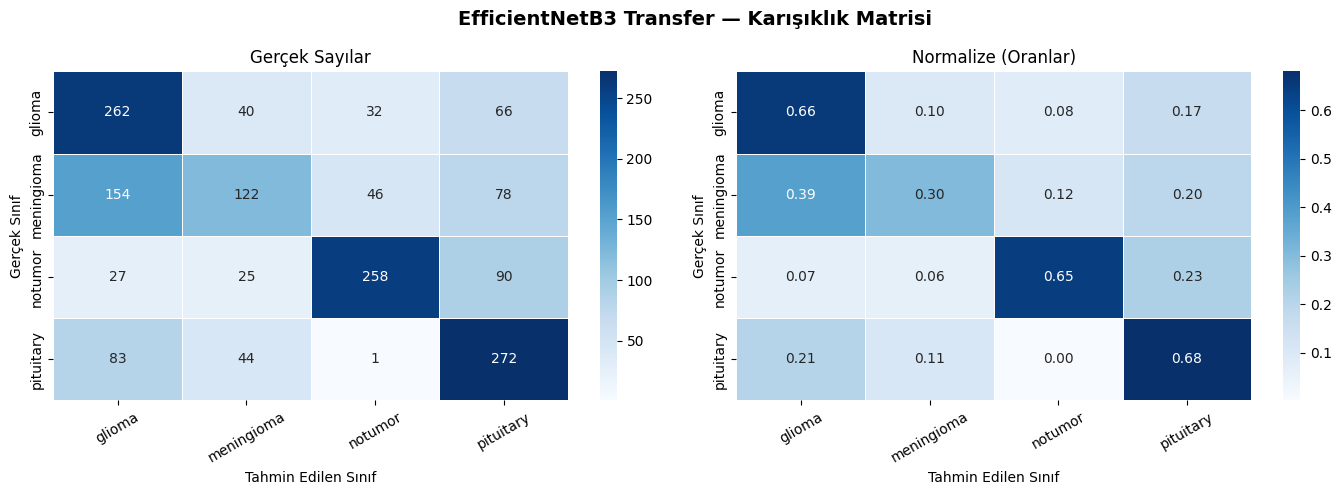

Kaydedildi: EfficientNetB3_Transfer_confusion_matrix.png


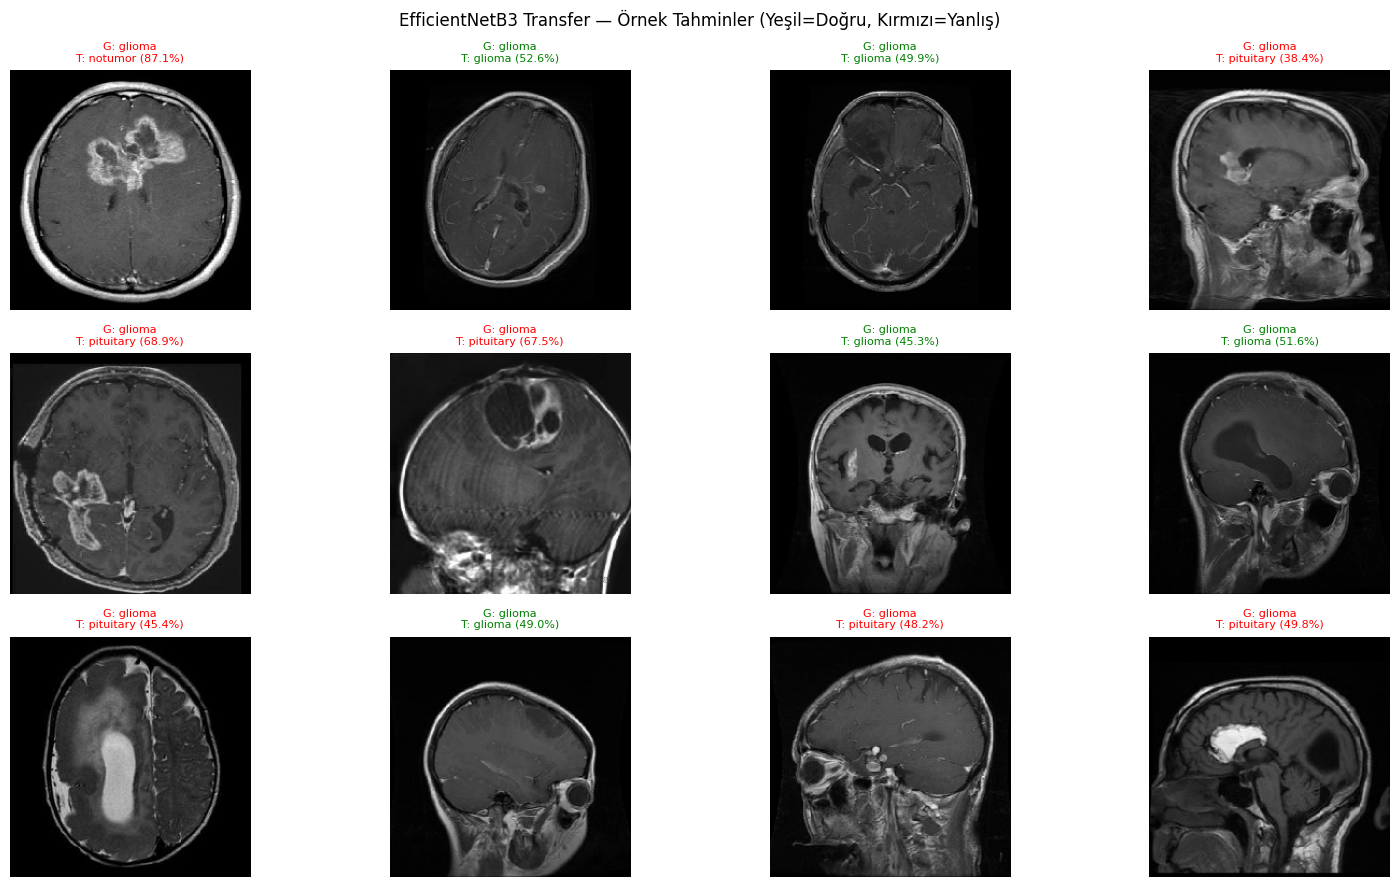

Kaydedildi: EfficientNetB3_Transfer_sample_preds.png


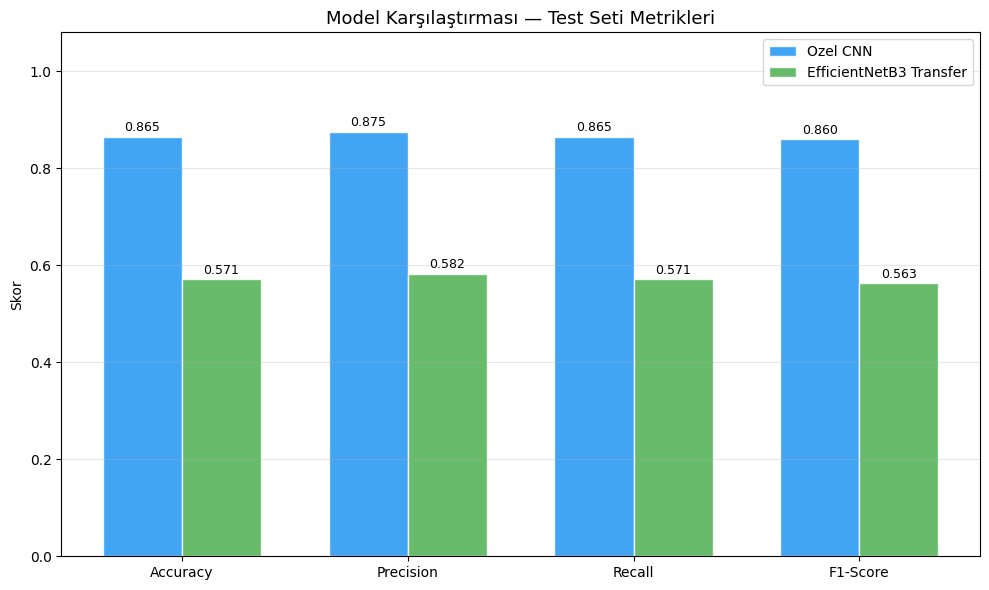

Kaydedildi: model_comparison.png


--- GRAD-CAM ANALİZİ (BONUS) ---


Grad-CAM için katman adını kontrol edin: No such layer: top_conv. Existing layers are: ['input', 'efficientnetb3', 'gap', 'fc1', 'bn_fc', 'drop_fc', 'output'].
Model katman isimleri:

Modeller kaydedildi:
  - brain_tumor_cnn_final.h5
  - brain_tumor_efficientnet_final.h5

  Proje tamamlandı!


In [ ]:
def main():
    print("\n" + "="*60)
    print("  MRI Beyin Tümörü Sınıflandırması — Başlıyor...")
    print("="*60 + "\n")

    # --- 1. Veri hazırlama ---
    train_gen, val_gen, test_gen = create_data_generators()
    print(f"\nEğitim görüntüsü  : {train_gen.samples}")
    print(f"Doğrulama görüntüsü: {val_gen.samples}")
    print(f"Test görüntüsü     : {test_gen.samples}")
    print(f"Sınıflar           : {list(train_gen.class_indices.keys())}")

    visualize_samples(train_gen)

    # --- 2. Model A: Özel CNN ---
    print("\n\n--- MODEL A: ÖZEL CNN EĞİTİLİYOR ---")
    cnn_model, cnn_history = train_cnn(train_gen, val_gen)
    plot_training_history(cnn_history, "Ozel CNN")
    y_true, y_pred_cnn, labels, cnn_metrics = evaluate_model(
        cnn_model, test_gen, "Ozel CNN")
    plot_confusion_matrix(y_true, y_pred_cnn, labels, "Ozel CNN")
    plot_sample_predictions(cnn_model, test_gen, model_name="Ozel CNN")

    # --- 3. Model B: Transfer Learning ---
    print("\n\n--- MODEL B: EfficientNetB3 TRANSFER EĞİTİLİYOR ---")
    tfer_model, tfer_history = train_transfer(train_gen, val_gen)
    plot_training_history(tfer_history, "EfficientNetB3 Transfer")
    test_gen.reset()
    y_true2, y_pred_tfer, labels2, tfer_metrics = evaluate_model(
        tfer_model, test_gen, "EfficientNetB3 Transfer")
    plot_confusion_matrix(y_true2, y_pred_tfer, labels2, "EfficientNetB3 Transfer")
    plot_sample_predictions(tfer_model, test_gen, model_name="EfficientNetB3 Transfer")

    # --- 4. Karşılaştırma ---
    plot_model_comparison({
        "Ozel CNN"             : cnn_metrics,
        "EfficientNetB3 Transfer": tfer_metrics
    })

    # --- 5. Grad-CAM (BONUS) ---
    # Test setinden rastgele bir görüntü seç
    sample_files = []
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(TEST_DIR, cls)
        if os.path.exists(cls_dir):
            files = os.listdir(cls_dir)
            if files:
                sample_files.append(os.path.join(cls_dir, files[0]))

    if sample_files:
        print("\n\n--- GRAD-CAM ANALİZİ (BONUS) ---")
        # EfficientNetB3'ün son konvolüsyon katmanı
        last_conv = "top_conv"   # EfficientNetB3 için standart isim
        try:
            display_gradcam(tfer_model, sample_files[0], last_conv_layer_name=last_conv)
        except Exception as e:
            print(f"Grad-CAM için katman adını kontrol edin: {e}")
            print("Model katman isimleri:")
            for layer in tfer_model.layers[-10:]:
                if "conv" in layer.name.lower():
                    print(f"  {layer.name}")

    # --- 6. Modelleri kaydet ---
    cnn_model.save("brain_tumor_cnn_final.h5")
    tfer_model.save("brain_tumor_efficientnet_final.h5")
    print("\nModeller kaydedildi:")
    print("  - brain_tumor_cnn_final.h5")
    print("  - brain_tumor_efficientnet_final.h5")

    print("\n" + "="*60)
    print("  Proje tamamlandı!")
    print("="*60)


if __name__ == "__main__":
    main()
